In [6]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec

# Defining Global Variable

In [15]:
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
theta = np.arcsin(x_star)

# Graphing Settings

In [9]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# 2-Qubit MSD Circuit

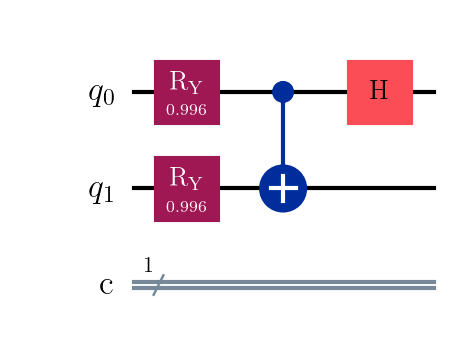

In [10]:
qc = QuantumCircuit(2,1)

# State preparation
qc.ry(theta,0)
qc.ry(theta,1)

# Distillation circuit
qc.cx(0,1)
qc.h(0)

display(qc.draw(output='mpl'))

# Infidelity to Error Rates

In [11]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [12]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [13]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

In [21]:
input_error_rate_list = np.linspace(0.5,0.9, 500)

Consider the case when only state preparation is noisy

In [22]:
ideal = QuantumCircuit(2)
ideal.ry(theta,0)
ideal_dm = DensityMatrix(ideal)

In [23]:
fid_list_noisy_prep = []
shots = 50

for i in range(len(input_error_rate_list)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(input_error_rate_list[i], 1),
        ['ry']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_dm, res_dm['0x0'][0])
    fid_list_noisy_prep.append(temp_fid)

infid_list_noisy_prep = [1-f for f in fid_list_noisy_prep]

In [31]:
# Finding the intersection of the curve with y=x
output_error_rate = inf_to_error(infid_list_noisy_prep, 1)
y = output_error_rate
x = input_error_rate_list

diff = y - x

# Find where the sign changes
idx = np.where(diff[:-1] * diff[1:] <= 0)[0][0]

# Interpolate intersection in log-log space
logx1, logx2 = np.log(x[idx]), np.log(x[idx + 1])
logy1, logy2 = np.log(y[idx]), np.log(y[idx + 1])

# Interpolate log(output/input)
f1 = logy1 - logx1
f2 = logy2 - logx2

logx_intersect = logx1 - f1 * (logx2 - logx1) / (f2 - f1)
x_intersect = np.exp(logx_intersect)
y_intersect = x_intersect

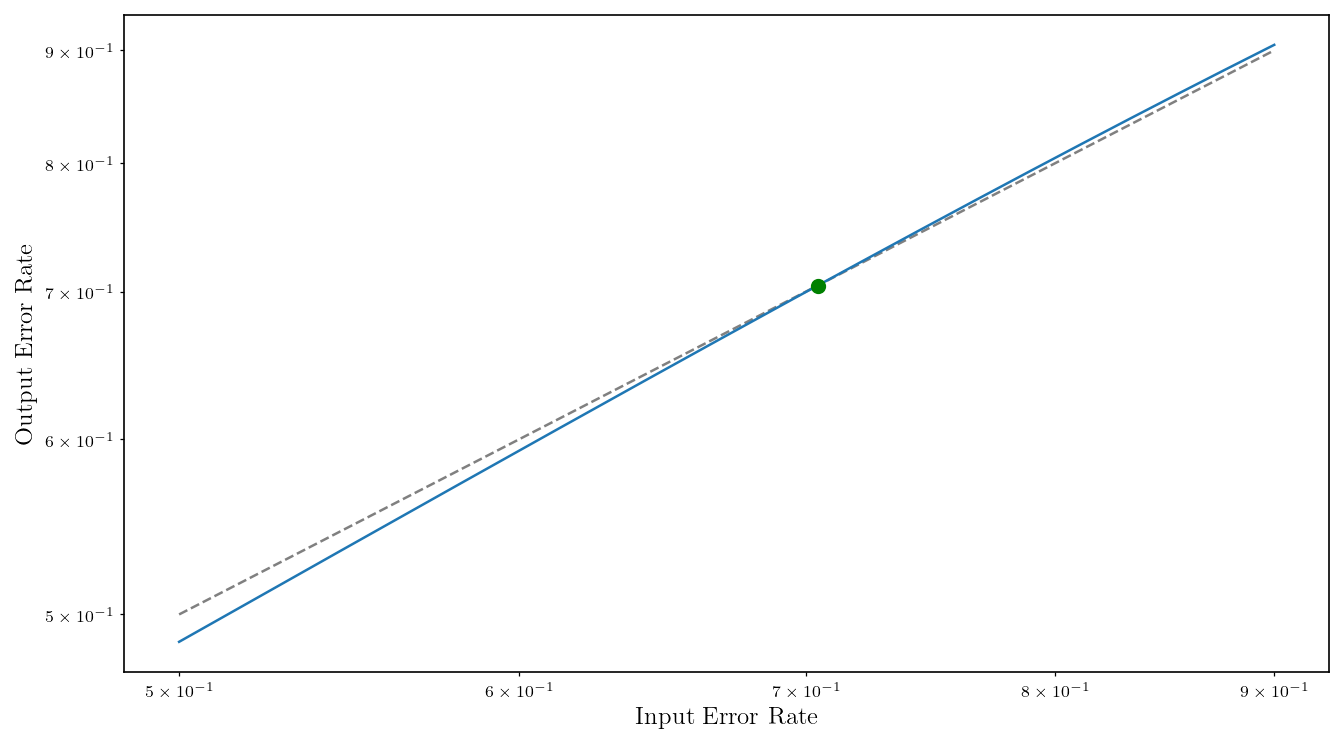

In [33]:
plt.figure(figsize=(9, 5))

plt.plot(input_error_rate_list, input_error_rate_list, color="gray", linestyle="--")
plt.plot(input_error_rate_list, output_error_rate)
plt.scatter(x_intersect, y_intersect, color="green", s=40, zorder=5,)
plt.xlabel("Input Error Rate", fontsize=12)
plt.ylabel("Output Error Rate", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [35]:
print(x_intersect)

0.7044023647315808


# Saving Data

In [37]:
np.savez(
    "depolarizing_error_rates.npz",
    input_error_rate_list=input_error_rate_list,
    output_error_rate=output_error_rate,
    intersection=x_intersect
)